# Data Sharing: Pretrained Model

---

This notebook will prepare a sharable file containing all required parameters allowing free use of the trained SNM-1000 in future works.


### Package imports and basic functions

---

In [1]:
import os
import gc
import sys
import glob
import shutil
import json
import random
import datetime
import importlib
import itertools
import numpy as np
from scipy import spatial
import scipy.sparse as sparse
import scipy.stats as stats
import pandas as pd
import nibabel as nib
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from tqdm.auto import tqdm
from urllib.parse import urlparse
import requests
import zipfile
from pathlib import Path
import polars as pl
import colorcet as cc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg
import joblib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec


In [2]:
%load_ext autoreload
%autoreload 2

# Path to add to src folder (to use local version of spectranorm)
sys.path.append(os.path.abspath("/mountpoint/code/projects/spectranorm/package/spectranorm/src/"))

from spectranorm import snm


In [3]:
class MyNumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)


def ensure_dir(file_name):
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    return file_name


def list_dirs(path=os.getcwd()):
    files = glob.glob(os.path.join(path, '*'))
    files = [x for x in files if os.path.isdir(x)]
    return files


def file_exists(file_name, path_name=os.getcwd()):
    return os.path.isfile(os.path.join(path_name, file_name))


def write_json(json_obj, file_path):
    with open(file_path, 'w') as outfile:
        json.dump(json_obj, outfile, sort_keys=True, indent=4,
                  cls=MyNumpyEncoder)
    return json_obj


def load_json(file_path):
    with open(file_path, 'r') as infile:
        return json.load(infile)


def write_np(np_obj, file_path):
    with open(file_path, 'wb') as outfile:
        np.save(outfile, np_obj)


In [4]:
from PIL import Image as PILImage
from IPython.display import display
import warnings

warnings.simplefilter('ignore', PILImage.DecompressionBombWarning)

def show_image(image_path, width=1000, resample=PILImage.LANCZOS):
    """
    Display an image in Jupyter at a fixed width while preserving aspect ratio.
    The image is resampled (not embedded full-size) to reduce notebook memory.
    """
    img = PILImage.open(image_path).copy()
    w, h = img.size
    new_h = int(h * width / w)
    img = img.resize((width, new_h), resample)
    display(img)


In [5]:
# use tex for plotting
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']


## Load Spectral Normative Model

---

Load the Spectral Normative Model (fitted in 05_01)


In [6]:
%%time
spectral_normative_model = snm.SpectralNormativeModel.load_model(
    "/mountpoint/code/projects/normative_brain_charts/data/pretrained_models/full_spectral_normative_model_10000/"
)
eigenmode_basis = spectral_normative_model.eigenmode_basis
spectral_normative_model


CPU times: user 15.6 s, sys: 3.22 s, total: 18.9 s
Wall time: 18.9 s


SpectralNormativeModel(eigenmode_basis=EigenmodeBasis(n_modes=10000, n_features=59412), base_model=DirectNormativeModel(spec=NormativeModelSpec(variable_of_interest='thickness', covariates=[CovariateSpec(name=age, cov_type=numerical, effect=spline), CovariateSpec(name=sex, cov_type=categorical, hierarchical=False, n_categories=2), CovariateSpec(name=site, cov_type=categorical, hierarchical=True, n_categories=189)], influencing_mean=['age', 'sex', 'site'], influencing_variance=['age', 'sex', 'site'])))

## Reduce loaded model

---

Our evaluations indicated that the first 1000 modes will be enough.


In [8]:
%%time
spectral_normative_model_1000 = spectral_normative_model.reduce_model(n_modes=1000)


CPU times: user 4.47 ms, sys: 145 μs, total: 4.62 ms
Wall time: 4.09 ms


## Save SNM-1000

---

The saved SNM-1000 will be made openly available.


In [12]:
%%time

# Store the reduced model for future use
save_path = "/mountpoint/code/projects/normative_brain_charts/data/pretrained_models/pretrained_SNM_1000_V1.0/"

# first remove any older saved models
if Path(save_path).exists():
    # for now let's replace with a warning as rewriting a pretrained and saved SNM can throw away valuable data
    raise RuntimeError("There seems to be a model saved previously, are you sure?")
    # shutil.rmtree(save_path)


# create the parent directory
Path(save_path).mkdir(parents=True, exist_ok=True)

# save the model
spectral_normative_model_1000.save_model(Path(save_path))


CPU times: user 8.12 s, sys: 479 ms, total: 8.6 s
Wall time: 8.6 s


## Verify model

---

The following script is to ensure the saved model functions as expected:


In [19]:
%%time
snm_1000 = snm.SpectralNormativeModel.load_model(
    "/mountpoint/code/projects/normative_brain_charts/data/pretrained_models/pretrained_SNM_1000_V1.0/"
)
snm_1000


CPU times: user 4.84 s, sys: 200 ms, total: 5.04 s
Wall time: 5.04 s


SpectralNormativeModel(eigenmode_basis=EigenmodeBasis(n_modes=1000, n_features=59412), base_model=DirectNormativeModel(spec=NormativeModelSpec(variable_of_interest='thickness', covariates=[CovariateSpec(name=age, cov_type=numerical, effect=spline), CovariateSpec(name=sex, cov_type=categorical, hierarchical=False, n_categories=2), CovariateSpec(name=site, cov_type=categorical, hierarchical=True, n_categories=189)], influencing_mean=['age', 'sex', 'site'], influencing_variance=['age', 'sex', 'site'])))

In [20]:
# let's define 10 queries for the first 10 modes
n_queries = 10
n_modes = 1000
encoded_queries = np.zeros((n_modes, n_queries))
np.fill_diagonal(encoded_queries, 1)
encoded_queries.shape, encoded_queries.sum()


((1000, 10), 10.0)

In [21]:
%%time
# generate predicted charts
ages = np.linspace(3, 97, 200)

# create dummy dataframe for prediction
dummy_df = pd.DataFrame({
    "age": ages,
})

# predict moments
predicted_spectral_moments = snm_1000.predict(
    encoded_query=encoded_queries[:n_queries],
    test_covariates=dummy_df, predict_without=['site', 'sex'],
    n_modes=n_queries, # to simplify the inference
).predictions


Computing direct eigenmode estimates:   0%|          | 0/10 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/29 [00:00<?, ?tasks/s]

CPU times: user 268 ms, sys: 134 ms, total: 402 ms
Wall time: 28.7 s


In [22]:
# Let's write a function to visualize the normative charts

def plot_charts(ax, dummy_ages, predicted_moments, query_index):
    # extract predicted moments
    y_ppc_mu_mean = predicted_moments['mu_estimate'][:, query_index]
    y_ppc_sigma_mean = predicted_moments['std_estimate'][:, query_index]

    quantiles = [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

    thickness_quantiles = {
        q: (
            (
                y_ppc_mu_mean + stats.norm.ppf(q=q) * (y_ppc_sigma_mean)
            )
        ) for q in quantiles
    }

    # colors for the plot
    c1 = '#448e9c'  # brighter shade
    c2 = '#038da6'  # darker shade

    # centile plots
    for q1, q2, alpha in [(0.001, 0.999, 0.05), (0.01, 0.99, 0.1), (0.05, 0.95, 0.2), (0.25, 0.75, 0.3)]:
        ax.fill_between(
            dummy_ages,
            thickness_quantiles[q1],
            thickness_quantiles[q2],
            alpha=alpha,
            color=c1,
        )

        # Now add boundary lines with different colors
        ax.plot(dummy_ages, thickness_quantiles[q1], color=c1, lw=0.5, linestyle=":",)
        ax.plot(dummy_ages, thickness_quantiles[q2], color=c1, lw=0.5, linestyle=":",)

    # Median
    ax.plot(
        dummy_ages,
        thickness_quantiles[0.5],
        c=c2,
        lw=4,
    )

    ax.set_xlim(3.5,96.5)
    
    ax.set_ylabel(f"Mode: {query_index + 1}")



CPU times: user 156 ms, sys: 0 ns, total: 156 ms
Wall time: 154 ms


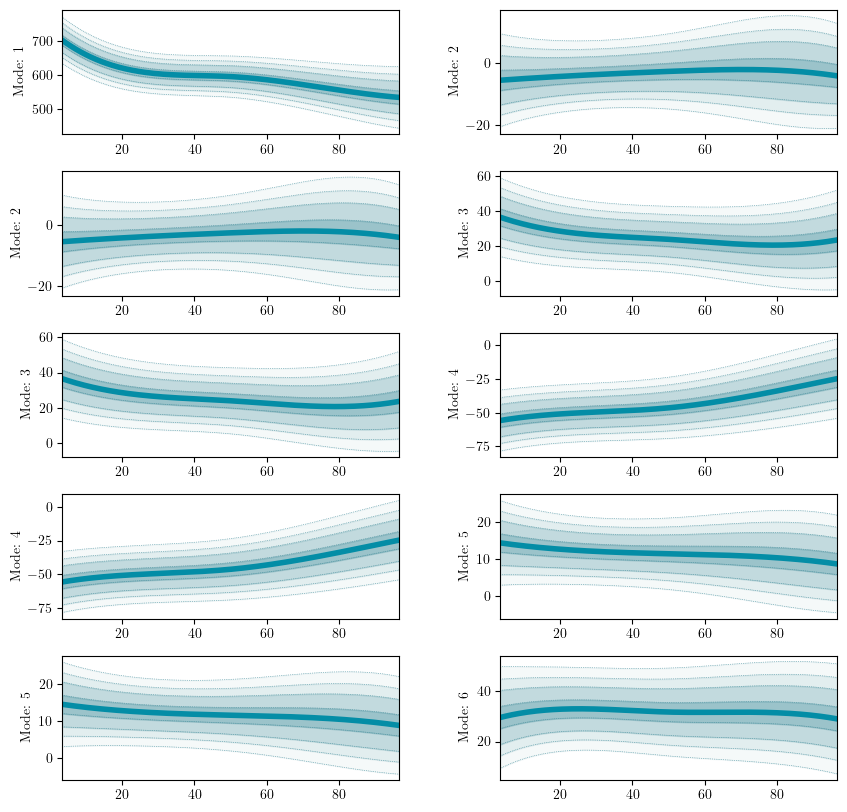

In [23]:
%%time
fig, axes = plt.subplots(5, 2, figsize=(10, 10))

# Adjust spacing
fig.subplots_adjust(
    wspace=0.3,  # width space between columns
    hspace=0.3   # height space between rows
)

for i in range(5):
    for j in range(2):
        plot_charts(
            ax=axes[i, j], dummy_ages=ages,
            predicted_moments=predicted_spectral_moments, query_index=(i + j),
        )
